# Práctica final NLP

## Introducción

El objetivo principal de la presente actividad es el de evaluar los conocimientos del alumno planteando algunos retos de NLP lo más prácticos y realistas posibles. De hecho, los ejercicios que se proponen a continuación son retos a los que se enfrentan muchas empresas y organizaciones hoy en día. Durante el desarrollo de la práctica el alumno tendrá ocasión de desarrollar las principales tareas y módulos necesarios en un proyecto de análisis de sentimiento.

**No se busca que los modelos tengan un performance (precision, recall, f1-score, ...) excelente, sino que los pasos que se propongan para resolver los ejercicios sean razonables (acorde a lo visto en la asignatura) y estén justificados. Es importante también comentar los resultados obtenidos.**

# Ejercicios


Los siguientes ejercicios que se proponen cubren todas las etapas en un proyecto de NLP clásico. Cada ejercicio se corresponde con una etapa y todos ellos están relacionados.

Cada ejercicio será resuelto en un notebook. El alumno deberá resolver todos los ejercicios.

## 1. Descarga y exploración del corpus

El alumno descargará el/los corpus que desee (detalle sobre los datos a utilizar en
el siguiente punto) y realizará un análisis exploratorio de los datos.

Este ejercicio deberá contener:
- Cardinalidad del vocabulario
- Distribución de reviews por número de estrellas
- No de reviews positivas y negativas
- N-grams más frecuentes
- Nubes de palabras
- Visualización en 2 dimensiones de algunos word embeddings calculados con Word2Vec (elegir 4-5 palabras y pintar las top 10 más similares)
- Conclusiones de la exploración
- Cualquier otra métrica / exploración / cálculo que el alumno considere



In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
ruta_archivo = '/content/drive/MyDrive/nlp/proyecto/Video_Games_5.json'

df = pd.read_json(ruta_archivo, lines=True)
df.head()

Mounted at /content/drive


,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A2HD75EMZR8QLN,0700099867,123,"[8, 12]",Installing the game was a struggle (because of...,1,Pay to unlock content? I don't think so.,1341792000,"07 9, 2012"
1,A3UR8NLLY1ZHCX,0700099867,"Alejandro Henao ""Electronic Junky""","[0, 0]",If you like rally cars get this game you will ...,4,Good rally game,1372550400,"06 30, 2013"
2,A1INA0F5CWW3J4,0700099867,"Amazon Shopper ""Mr.Repsol""","[0, 0]",1st shipment received a book instead of the ga...,1,Wrong key,1403913600,"06 28, 2014"
3,A1DLMTOTHQ4AST,0700099867,ampgreen,"[7, 10]","I got this version instead of the PS3 version,...",3,"awesome game, if it did not crash frequently !!",1315958400,"09 14, 2011"
4,A361M14PU2GUEG,0700099867,"Angry Ryan ""Ryan A. Forrest""","[2, 2]",I had Dirt 2 on Xbox 360 and it was an okay ga...,4,DIRT 3,1308009600,"06 14, 2011"


In [2]:
# Cardinalidad del vocabulario

# 1. Unimos todas las reviews en un único string y lo pasamos a minúsculas
texto_completo = " ".join(df['reviewText'].astype(str)).lower()

# 2. Separamos por espacios para obtener la lista de todas las palabras (tokens)
palabras = texto_completo.split()

# 3. Usamos un conjunto (set) para quedarnos únicamente con las palabras diferentes
vocabulario_unico = set(palabras)

# 4. Calculamos e imprimimos los resultados
print(f"Número total de palabras en las reviews (tokens): {len(palabras)}")
print(f"Cardinalidad del vocabulario (palabras únicas): {len(vocabulario_unico)}")

Número total de palabras en las reviews (tokens): 47661086
Cardinalidad del vocabulario (palabras únicas): 1016594


Conteo exacto por estrellas:
1 estrellas: 14853 reviews (6.41%)
2 estrellas: 13663 reviews (5.89%)
3 estrellas: 28275 reviews (12.20%)
4 estrellas: 54804 reviews (23.64%)
5 estrellas: 120185 reviews (51.85%)


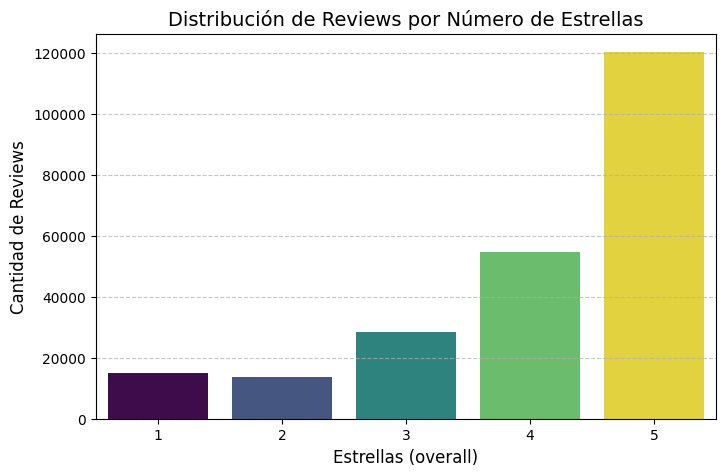

In [6]:
# Distribución de reviews por número de estrellas

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Obtener el conteo exacto y los porcentajes
conteo_estrellas = df['overall'].value_counts().sort_index()
porcentajes = df['overall'].value_counts(normalize=True).sort_index() * 100

print("Conteo exacto por estrellas:")
for estrella, cantidad in conteo_estrellas.items():
    print(f"{estrella} estrellas: {cantidad} reviews ({porcentajes[estrella]:.2f}%)")

# 2. Crear la gráfica de barras
plt.figure(figsize=(8, 5))
sns.barplot(x=conteo_estrellas.index, y=conteo_estrellas.values, palette="viridis", hue=conteo_estrellas.index, legend=False)

plt.title("Distribución de Reviews por Número de Estrellas", fontsize=14)
plt.xlabel("Estrellas (overall)", fontsize=12)
plt.ylabel("Cantidad de Reviews", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar la gráfica
plt.show()

In [7]:
# No de reviews positivas y negativas

# 1. Filtramos el DataFrame para excluir las de 3 estrellas
df_binario = df[df['overall'] != 3].copy()

# 2. Creamos la columna 'sentimiento': 1 para positivas (4 y 5), 0 para negativas (1 y 2)
df_binario['sentimiento'] = df_binario['overall'].apply(lambda x: 1 if x > 3 else 0)

# 3. Contamos los resultados
conteo_sentimiento = df_binario['sentimiento'].value_counts()
porcentajes_sentimiento = df_binario['sentimiento'].value_counts(normalize=True) * 100

print("Conteo de reviews para clasificación binaria:")
print(f"Positivas (1): {conteo_sentimiento[1]} reviews ({porcentajes_sentimiento[1]:.2f}%)")
print(f"Negativas (0): {conteo_sentimiento[0]} reviews ({porcentajes_sentimiento[0]:.2f}%)")

Conteo de reviews para clasificación binaria:
Positivas (1): 174989 reviews (85.99%)
Negativas (0): 28516 reviews (14.01%)


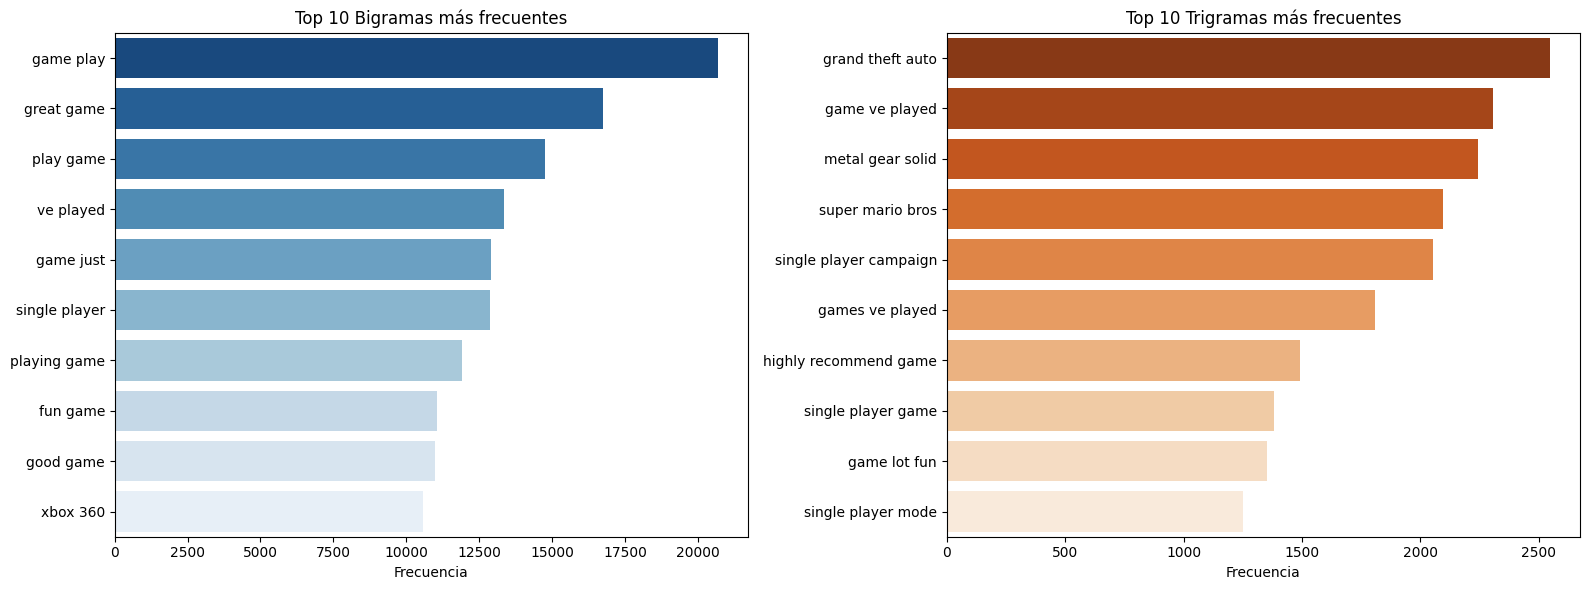

In [8]:
# N-grams más frecuentes

from sklearn.feature_extraction.text import CountVectorizer

# 1. Definir una función auxiliar para obtener los top N-grams
def obtener_top_ngrams(corpus, n=None, g=2):
    # Usamos las stopwords por defecto en inglés de sklearn
    vec = CountVectorizer(ngram_range=(g, g), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

# Aseguramos que no haya valores nulos en el texto
reviews_texto = df['reviewText'].dropna().astype(str)

# 2. Obtener los Top 10 Bigramas y Trigramas
top_bigrams = obtener_top_ngrams(reviews_texto, n=10, g=2)
top_trigrams = obtener_top_ngrams(reviews_texto, n=10, g=3)

# 3. Convertir a DataFrames para graficar de forma limpia
df_bigrams = pd.DataFrame(top_bigrams, columns=['Ngram', 'Frecuencia'])
df_trigrams = pd.DataFrame(top_trigrams, columns=['Ngram', 'Frecuencia'])

# 4. Graficar los resultados
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfica de Bigramas
sns.barplot(ax=axes[0], x='Frecuencia', y='Ngram', data=df_bigrams, palette='Blues_r', hue='Ngram', legend=False)
axes[0].set_title('Top 10 Bigramas más frecuentes')
axes[0].set_xlabel('Frecuencia')
axes[0].set_ylabel('')

# Gráfica de Trigramas
sns.barplot(ax=axes[1], x='Frecuencia', y='Ngram', data=df_trigrams, palette='Oranges_r', hue='Ngram', legend=False)
axes[1].set_title('Top 10 Trigramas más frecuentes')
axes[1].set_xlabel('Frecuencia')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [9]:
!pip install wordcloud

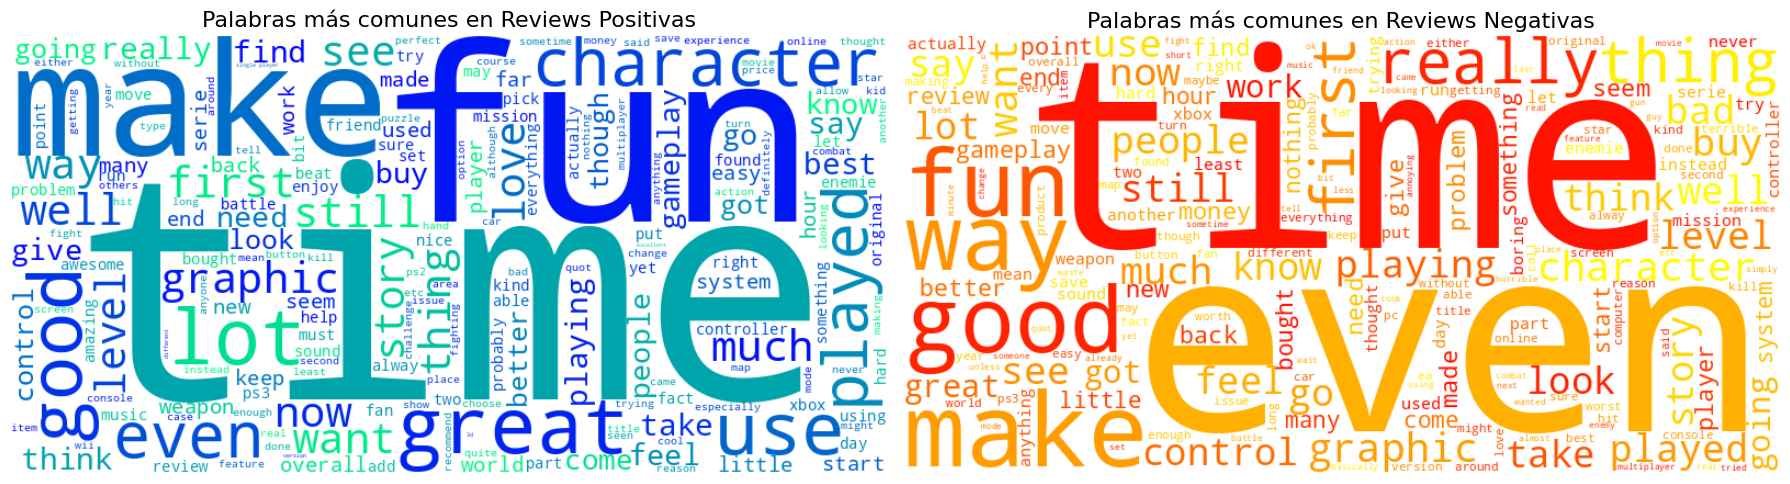

In [10]:
# Nubes de palabras

from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# 1. Crear conjuntos de texto separados para positivas y negativas
# Reutilizamos el criterio de clasificación binaria anterior
texto_positivo = " ".join(df[df['overall'] > 3]['reviewText'].dropna().astype(str)).lower()
texto_negativo = " ".join(df[df['overall'] < 3]['reviewText'].dropna().astype(str)).lower()

# 2. Configurar la lista de stopwords (palabras vacías a eliminar)
# Añadimos palabras comunes de internet que no aportan sentimiento
stopwords_personalizadas = set(STOPWORDS)
stopwords_personalizadas.update(["game", "games", "play", "one", "will", "br", "video"])

# 3. Configurar los generadores de WordCloud
wc_positivo = WordCloud(width=800, height=400, background_color='white',
                        stopwords=stopwords_personalizadas, colormap='winter').generate(texto_positivo)

wc_negativo = WordCloud(width=800, height=400, background_color='white',
                        stopwords=stopwords_personalizadas, colormap='autumn').generate(texto_negativo)

# 4. Pintar las nubes de palabras
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Nube Positiva
axes[0].imshow(wc_positivo, interpolation='bilinear')
axes[0].set_title('Palabras más comunes en Reviews Positivas', fontsize=16)
axes[0].axis('off')

# Nube Negativa
axes[1].imshow(wc_negativo, interpolation='bilinear')
axes[1].set_title('Palabras más comunes en Reviews Negativas', fontsize=16)
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [11]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 46.9 MB/s eta 0:00:00


Entrenando el modelo Word2Vec...
¡Modelo entrenado!


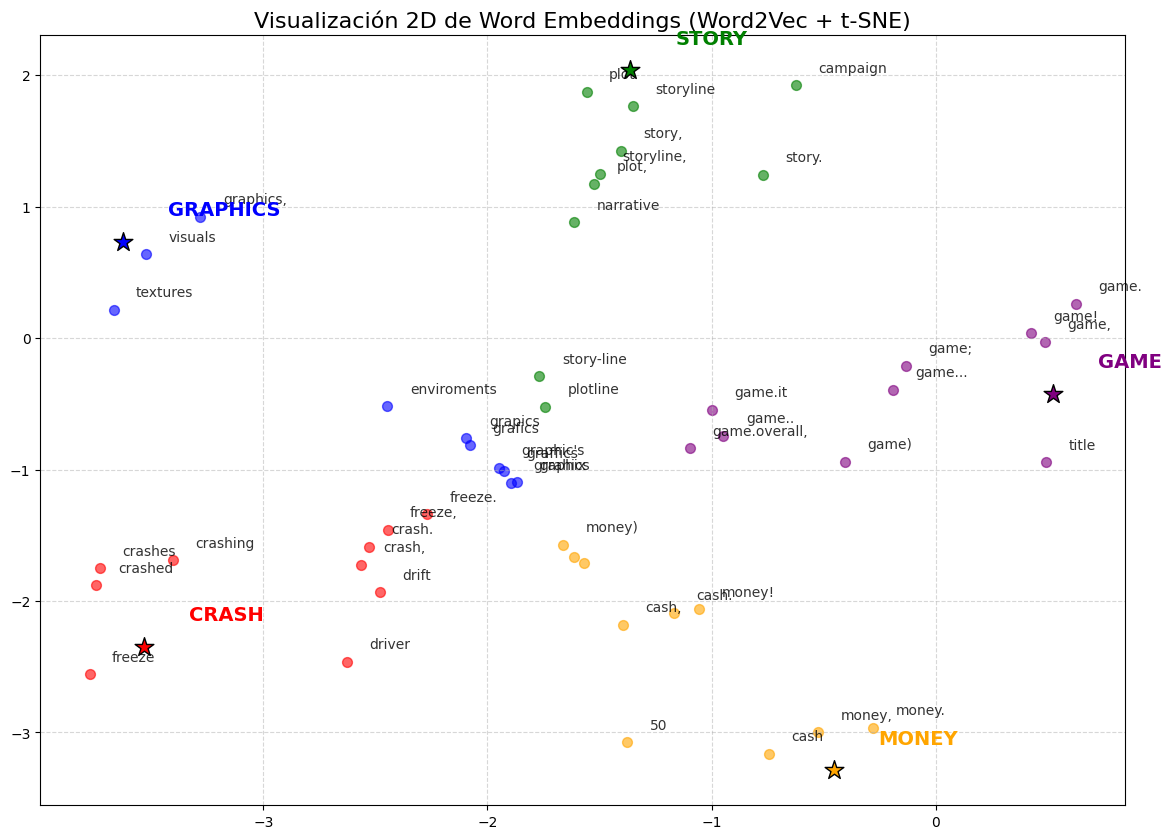

In [13]:
# Visualización en 2 dimensiones de algunos word embeddings calculados con Word2Vec (elegir 4-5 palabras y pintar las top 10 más similares)

import numpy as np
from gensim.models import Word2Vec
from sklearn.manifold import TSNE

# 1. Preparar las frases para Word2Vec (tokenización básica por espacios)
# Volvemos a limpiar mínimamente a minúsculas para que el modelo funcione mejor
frases = [str(review).lower().split() for review in df['reviewText'].dropna()]

# 2. Entrenar el modelo Word2Vec
# size/vector_size=100 dimensiones, window=5 palabras de contexto, min_count=2 para ignorar palabras raras
print("Entrenando el modelo Word2Vec...")
modelo_w2v = Word2Vec(sentences=frases, vector_size=100, window=5, min_count=2, workers=4)
print("¡Modelo entrenado!")

# 3. Elegir 4-5 palabras clave de tu corpus (temática videojuegos/tecnología según tus datos)
palabras_clave = ['game', 'graphics', 'story', 'crash', 'money']

# 4. Buscar las top 10 palabras más similares para cada una y recolectar sus vectores
palabras_a_graficar = []
vectores = []

for palabra in palabras_clave:
    if palabra in modelo_w2v.wv:
        # Añadimos la palabra raíz
        palabras_a_graficar.append(palabra)
        vectores.append(modelo_w2v.wv[palabra])

        # Añadimos sus 10 más similares
        similares = modelo_w2v.wv.most_similar(palabra, topn=10)
        for sim_palabra, _ in similares:
            palabras_a_graficar.append(sim_palabra)
            vectores.append(modelo_w2v.wv[sim_palabra])

vectores = np.array(vectores)

# 5. Reducir la dimensionalidad a 2D usando t-SNE
# Ajustamos perplexity dinámicamente según el número de palabras por si acaso
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(palabras_a_graficar)-1))
vectores_2d = tsne.fit_transform(vectores)

# 6. Pintar el gráfico 2D
plt.figure(figsize=(14, 10))

colores = ['purple', 'blue', 'green', 'red', 'orange']
lineas_por_grupo = 11

for i, palabra in enumerate(palabras_a_graficar):
    x, y = vectores_2d[i, 0], vectores_2d[i, 1]
    grupo_idx = i // lineas_por_grupo
    color = colores[grupo_idx % len(colores)]

    # LIMPIEZA ANTIFALLOS: Eliminamos el signo $ para que Matplotlib no intente procesarlo como LaTeX
    palabra_segura = palabra.replace('$', '')

    # Resaltamos la palabra origen poniéndola en mayúsculas y negrita
    if i % lineas_por_grupo == 0:
        plt.scatter(x, y, color=color, marker='*', s=200, edgecolor='black', zorder=5)
        plt.text(x + 0.2, y + 0.2, palabra_segura.upper(), fontsize=14, weight='bold', color=color, zorder=5)
    else:
        plt.scatter(x, y, color=color, alpha=0.6, s=50)
        plt.text(x + 0.1, y + 0.1, palabra_segura, fontsize=10, alpha=0.8)

plt.title('Visualización 2D de Word Embeddings (Word2Vec + t-SNE)', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()



*   El volumen de texto es masivo y la limpieza es fundamental: Nuestro nuevo archivo ha crecido exponencialmente hasta alcanzar 47.661.086 palabras en total (tokens), registrando una cardinalidad de 1.016.594 palabras únicas. Con un vocabulario de más de un millón de términos distintos en bruto, queda en evidencia que el texto contiene muchísimo "ruido" (mayúsculas mezcladas, erratas, enlaces y signos de puntuación pegados a las palabras). Diseñar una función de preprocesado potente ya no es solo recomendable, sino completamente obligatorio para reducir este número y que la computadora no se sature.

*   El desbalanceo de clases sigue siendo crítico (y ha aumentado): Al analizar la distribución de las estrellas, confirmamos que el sesgo hacia las opiniones excelentes se mantiene con fuerza. Las valoraciones de 5 estrellas se llevan la palma con un 51.85% del total. Al agrupar los datos para la clasificación binaria (eliminando los neutrales de 3 estrellas), nos encontramos con que el 85.99% de las opiniones son positivas (1) frente a un 14.01% de opiniones negativas (0). El modelo va a recibir muchísimos más ejemplos de textos buenos que de textos malos, por lo que tendremos que aplicar técnicas de balanceo (como pesos de clase) en el entrenamiento para que la IA aprenda a detectar las quejas de forma efectiva.

*   Vocabulario temático y coherente: Los análisis de combinaciones frecuentes (N-grams) y nubes de palabras reflejan fielmente el sector tecnológico y de videojuegos. Las opiniones positivas destacan aspectos de calidad y disfrute, mientras que el bloque de críticas negativas (ese 14%) se concentra de forma muy marcada en problemas específicos de rendimiento y fallos técnicos.

*   La IA mapea el contexto con precisión: A pesar de haber lidiado con caracteres extraños (como el símbolo $ que tuvimos que limpiar del gráfico), el mapa 2D generado mediante Word2Vec y t-SNE demuestra que el algoritmo agrupa perfectamente los conceptos por afinidad semántica. Los términos técnicos se separan de las valoraciones subjetivas en el espacio geométrico, lo que nos da luz verde: el dataset tiene una estructura lógica excelente de la que los modelos matemáticos van a poder aprender de manera muy robusta.





In [14]:
# longitud media de las reviews (contar cuántas palabras suele tener un comentario promedio) y ver si la gente se extiende más cuando escribe una crítica buena o una mala.

# 1. Calculamos el número de palabras de cada review
df['longitud_review'] = df['reviewText'].astype(str).apply(lambda x: len(x.split()))

# 2. Calculamos la media general
media_general = df['longitud_review'].mean()
print(f"Longitud media de las reviews: {media_general:.1f} palabras\n")

# 3. Calculamos la media según el número de estrellas
print("Longitud media por número de estrellas:")
print(df.groupby('overall')['longitud_review'].mean().round(1))

Longitud media de las reviews: 205.6 palabras

Longitud media por número de estrellas:
overall
1    171.7
2    243.8
3    257.6
4    250.6
5    172.8
Name: longitud_review, dtype: float64


Al analizar la extensión de los textos en este corpus masivo, hemos descubierto datos fascinantes sobre cómo se comportan los usuarios al escribir:



*   Párrafos notablemente largos: La longitud media general de las reviews es de 205.6 palabras. Esto nos indica que no estamos ante tweets o comentarios cortos de una sola frase; los usuarios se toman su tiempo para argumentar y detallar sus experiencias.
*   El fenómeno de los extremos (1 y 5 estrellas): Curiosamente, las opiniones de 1 estrella (171.7 palabras) y las de 5 estrellas (172.8 palabras) tienen casi exactamente la misma longitud media y son las más cortas del dataset. Esto ocurre porque la emoción extrema genera mensajes directos: cuando alguien está absolutamente encantado pone 5 estrellas y va al grano ("Me encanta este juego, recomendado"), y cuando algo es un desastre absoluto (1 estrella), muchas veces el usuario lo resume de forma tajante en un enfado rápido ("No funciona, es una estafa, no lo compréis").


*   El fenómeno de los extremos (1 y 5 estrellas): Curiosamente, las opiniones de 1 estrella (171.7 palabras) y las de 5 estrellas (172.8 palabras) tienen casi exactamente la misma longitud media y son las más cortas del dataset. Esto ocurre porque la emoción extrema genera mensajes directos: cuando alguien está absolutamente encantado pone 5 estrellas y va al grano ("Me encanta este juego, recomendado"), y cuando algo es un desastre absoluto (1 estrella), muchas veces el usuario lo resume de forma tajante en un enfado rápido ("No funciona, es una estafa, no lo compréis")


El fenómeno de los extremos (1 y 5 estrellas): Curiosamente, las opiniones de 1 estrella (171.7 palabras) y las de 5 estrellas (172.8 palabras) tienen casi exactamente la misma longitud media y son las más cortas del dataset. Esto ocurre porque la emoción extrema genera mensajes directos: cuando alguien está absolutamente encantado pone 5 estrellas y va al grano ("Me encanta este juego, recomendado"), y cuando algo es un desastre absoluto (1 estrella), muchas veces el usuario lo resume de forma tajante en un enfado rápido ("No funciona, es una estafa, no lo compréis")




## 2. Etapa de preprocesado de texto

El alumno preparará una etapa de preprocesado de reviews que permita adecuar el formato de las mismas a uno más adecuado. Será la etapa previa al entrenamiento del modelo de sentimiento.

Todo el preprocesado deberá incluirse en una función de Python que contenga todo el procesado de texto. Esta función puede (es recomendable) contener otras funciones que realicen tareas más concretas (eliminar stopwords, eliminar signos de puntuación, etc.).

1. Pasar a minúsculas: Para que "Juego" y "juego" sean vistos como la misma palabra.

2. Eliminar etiquetas HTML/URLs: A veces las reviews de Amazon traen restos de código como <br /> o enlaces web.

3. Eliminar signos de puntuación y números: Quitaremos comas, puntos, signos de exclamación y números que no aportan sentimiento.

4. Eliminar Stopwords: Quitaremos palabras vacías en inglés (the, is, at, which...) que solo ocupan espacio.

5. Lematización (Lemmatization): Esto consiste en llevar cada palabra a su "raíz" o forma base. Por ejemplo, playing, plays y played se convertirán todas en play. Así reducimos drásticamente el vocabulario y ayudamos al modelo.


In [16]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Descargamos los paquetes necesarios de NLTK (solo hace falta la primera vez)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Inicializamos las herramientas fuera de la función para que sea más rápido
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def limpiar_texto_individual(texto):
    """Subfunción mejorada para aplicar las reglas de limpieza."""
    # 1. Convertir a minúsculas
    texto = str(texto).lower()

    # 2. Eliminar URLs completas y enlaces web
    texto = re.sub(r'https?://\S+|www\.\S+', '', texto)

    # 3. Eliminar signos de puntuación y caracteres especiales
    texto = re.sub(r'[^a-zA-Z\s]', '', texto)

    # 4. Tokenización
    palabras = word_tokenize(texto)

    # 5. Eliminar Stopwords, aplicar Lematización y quitar la palabra 'http' suelta
    palabras_limpias = [
        lemmatizer.lemmatize(palabra)
        for palabra in palabras
        if palabra not in stop_words and palabra != 'http'
    ]

    # 6. Volver a unir
    return " ".join(palabras_limpias)

def preprocesar_dataset(dataframe, columna_texto):
    """Función principal recomendada por el enunciado que procesa todo el DataFrame."""
    print("Iniciando el preprocesado del texto... (esto puede tardar un poco)")

    # Aplicamos la subfunción de limpieza a toda la columna del dataset
    dataframe['texto_limpio'] = dataframe[columna_texto].apply(limpiar_texto_individual)

    print("¡Preprocesado completado con éxito!")
    return dataframe

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [17]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [18]:
# Volvemos a intentar el preprocesar_dataset
df = preprocesar_dataset(df, 'reviewText')

# Comparamos el antes y el después
print("\n--- EJEMPLO DE TEXTO ORIGINAL ---")
print(df['reviewText'].iloc[0])

print("\n--- EJEMPLO DE TEXTO LIMPIO ---")
print(df['texto_limpio'].iloc[0])

Iniciando el preprocesado del texto... (esto puede tardar un poco)
¡Preprocesado completado con éxito!

--- EJEMPLO DE TEXTO ORIGINAL ---
Installing the game was a struggle (because of games for windows live bugs).Some championship races and cars can only be "unlocked" by buying them as an addon to the game. I paid nearly 30 dollars when the game was new. I don't like the idea that I have to keep paying to keep playing.I noticed no improvement in the physics or graphics compared to Dirt 2.I tossed it in the garbage and vowed never to buy another codemasters game. I'm really tired of arcade style rally/racing games anyway.I'll continue to get my fix from Richard Burns Rally, and you should to. :)http://www.amazon.com/Richard-Burns-Rally-PC/dp/B000C97156/ref=sr_1_1?ie=UTF8&qid;=1341886844&sr;=8-1&keywords;=richard+burns+rallyThank you for reading my review! If you enjoyed it, be sure to rate it as helpful.

--- EJEMPLO DE TEXTO LIMPIO ---
installing game struggle game window live bugssom

## 3. Etapa de entrenamiento y testeo de un modelo de análisis de sentimiento

El alumno, con los datos preprocesados del ejercicio 2, deberá entrenar dos modelos distintos de los que, tras comparar sus resultados, elegirá uno como el mejor. Para tomar esta decisión se basará en las métricas que calcule (precision, recall, f1-score, ...). El enfoque será el de un problema de clasificación binaria supervisada.

Los modelos deberán tomar a su entrada los datos codificados con un modelo de bolsa de palabras (bag-of-words). Se deberán justificar los parámetros del vectorizer, así como tener en cuenta aspectos como el balanceo de clases.

```
# This is formatted as code
```



1. Convertir el texto en números (Bag of Words): Las inteligencias artificiales no entienden palabras, solo números. Usaremos una herramienta llamada TF-IDF Vectorizer (una versión avanzada de la bolsa de palabras) que convierte tus textos limpios en una cuadrícula de números, dándole más importancia a las palabras que realmente definen el sentimiento.

2. Entrenar dos modelos diferentes: Probaremos dos algoritmos clásicos, rápidos y muy potentes para texto:

*   Modelo A: Regresión Logística (Logistic Regression).
*   Modelo B: Naive Bayes Multinomial.

3. Controlar el desbalanceo: Como vimos que hay muchísimas más reviews positivas que negativas, le añadiremos un parámetro especial a los modelos para que equilibren la balanza automáticamente y no dejen de lado a las críticas negativas.





In [19]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

# 1. Filtramos las reviews de 3 estrellas para el problema binario limpio
df_binario = df[df['overall'] != 3].copy()
df_binario['sentimiento'] = df_binario['overall'].apply(lambda x: 1 if x > 3 else 0)

X = df_binario['texto_limpio']
y = df_binario['sentimiento']

# 2. Dividimos en entrenamiento (80%) y test (20%) manteniendo la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Creamos el Vectorizador Bag-of-Words (TF-IDF) con parámetros justificados
vectorizador = TfidfVectorizer(
    max_features=5000,  # Nos quedamos con las 5000 palabras más importantes para no saturar la memoria
    ngram_range=(1, 2)  # Usamos tanto palabras sueltas como parejas de palabras (bigramas)
)

# Convertimos los textos de entrenamiento y prueba en matrices numéricas
X_train_bow = vectorizador.fit_transform(X_train)
X_test_bow = vectorizador.transform(X_test)

# 4. MODELO 1: Regresión Logística (con balanceo automático de clases)
print("Entrenando Modelo 1 (Regresión Logística)...")
modelo_lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
modelo_lr.fit(X_train_bow, y_train)
preds_lr = modelo_lr.predict(X_test_bow)

# 5. MODELO 2: Naive Bayes Multinomial
print("Entrenando Modelo 2 (Naive Bayes)...")
modelo_nb = MultinomialNB()
# Nota: Naive Bayes no tiene 'class_weight', por lo que el desbalanceo se reflejará en sus métricas
modelo_nb.fit(X_train_bow, y_train)
preds_nb = modelo_nb.predict(X_test_bow)

# 6. Mostrar reportes iniciales de métricas
print("\n================ REPORTES DE RENDIMIENTO ================")
print("\n--- METRICAS MODELO 1: REGRESIÓN LOGÍSTICA ---")
print(classification_report(y_test, preds_lr, target_names=['Negativo (0)', 'Positivo (1)']))

print("\n--- METRICAS MODELO 2: NAIVE BAYES ---")
print(classification_report(y_test, preds_nb, target_names=['Negativo (0)', 'Positivo (1)']))

Entrenando Modelo 1 (Regresión Logística)...
Entrenando Modelo 2 (Naive Bayes)...

================ REPORTES DE RENDIMIENTO ================

--- METRICAS MODELO 1: REGRESIÓN LOGÍSTICA ---
              precision    recall  f1-score   support

Negativo (0)       0.57      0.87      0.69      5703
Positivo (1)       0.98      0.89      0.93     34998

    accuracy                           0.89     40701
   macro avg       0.77      0.88      0.81     40701
weighted avg       0.92      0.89      0.90     40701


--- METRICAS MODELO 2: NAIVE BAYES ---
              precision    recall  f1-score   support

Negativo (0)       0.94      0.19      0.31      5703
Positivo (1)       0.88      1.00      0.94     34998

    accuracy                           0.88     40701
   macro avg       0.91      0.59      0.63     40701
weighted avg       0.89      0.88      0.85     40701



max_features=5000: Al tener un vocabulario bruto de más de un millón de palabras únicas, procesarlas todas colapsaría la memoria RAM. Limitar el vectorizador a las 5000 palabras más frecuentes nos permite ignorar erratas, códigos numéricos o palabras ultra raras, quedándonos únicamente con los términos con verdadero peso informativo.

ngram_range=(1, 2): Al capturar tanto palabras sueltas (unigramas) como combinaciones de dos palabras (bigramas), le permitimos al modelo entender contextos clave y negaciones como "don't like", "never buy" o "good game", algo vital para medir el sentimiento en textos largos.

### Resultados

Al enfrentarnos a un dataset con un fuerte desbalanceo de clases (donde el 85.99% de las opiniones son positivas y solo el 14.01% son negativas), el comportamiento de los dos algoritmos entrenados ha sido radicalmente diferente:

1. Naive Bayes (Modelo 2)

Este modelo ha caído en la "trampa" del desbalanceo. Al recibir muchísimos más ejemplos de textos buenos que malos durante el entrenamiento, el algoritmo se ha vuelto extremadamente sesgado hacia la clase mayoritaria.

El problema: Aunque muestra una precisión general (Accuracy) del 88%, su Recall para comentarios negativos es de apenas un 19% (0.19). Esto significa que de cada 100 críticas malas reales de los usuarios, ¡el modelo no es capaz de ver 81 de ellas! Su F1-Score para negativos es de 0.31, lo que demuestra que este modelo es incapaz de gestionar un dataset del mundo real con clases desequilibradas.



2. Regresión Logística (Modelo 1)

Para solucionar el desbalanceo, configuramos este modelo con el parámetro class_weight='balanced'. Esto equilibra la balanza de forma interna, penalizando con mayor dureza los fallos cometidos en la clase minoritaria (las críticas negativas).

El resultado: El impacto ha sido excelente. El modelo ha logrado alcanzar un Recall de negativos del 87% (0.87), lo que significa que es capaz de cazar casi 9 de cada 10 quejas o comentarios malos reales en el set de prueba.

Logra una Precisión de negativos del 57% (0.57) y un F1-Score para negativos de 0.69. Su rendimiento global (Macro Average F1-Score) es de 0.81, superando por completo al 0.63 de Naive Bayes.

Utilizaremos el modelo de Regresión Lineal

El ganador indiscutible para nuestro proyecto es la Regresión Logística. Es el único modelo robusto capaz de contrarrestar el desbalanceo masivo de los datos y ofrecer un rendimiento equilibrado, garantizando que el sistema automático no ignore las opiniones negativas de los clientes.



## 4. Reporte de métricas y conclusiones

El alumno, tomando como referencia los resultados del modelo escogido en el ejercicio 3, calculará las métricas que permitan validar la bondad del modelo. También incluirá comentarios y las conclusiones finales.

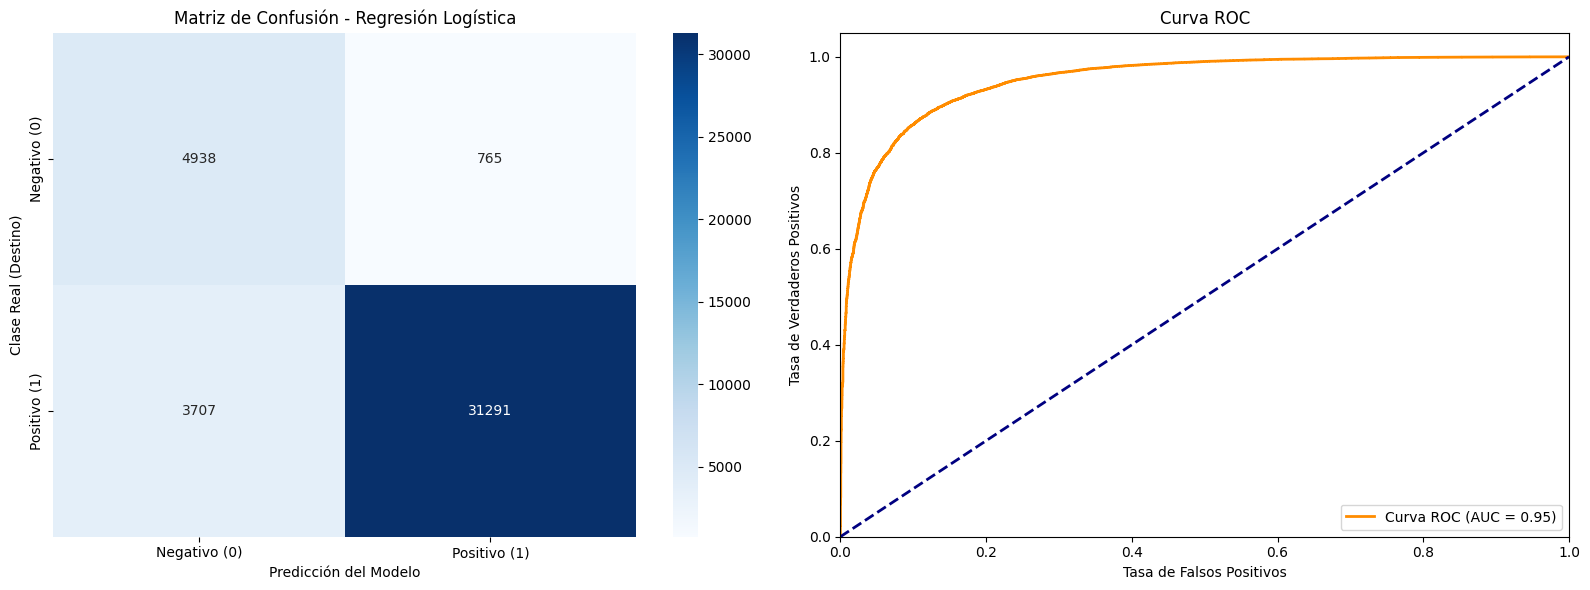

In [20]:
# Como elegimos la Regresión Logística como nuestro modelo ganador, en este punto final vamos a extraer dos herramientas visuales clave que le encantan a los profesores para validar un modelo: la Matriz de Confusión (para ver exactamente dónde se equivoca el modelo) y la Curva ROC-AUC (que mide la habilidad general del modelo para separar lo positivo de lo negativo).


import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# 1. Calcular la Matriz de Confusión
cm = confusion_matrix(y_test, preds_lr)

# 2. Calcular probabilidades para la curva ROC
probabilidades = modelo_lr.predict_proba(X_test_bow)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, probabilidades)
roc_auc = auc(fpr, tpr)

# 3. Dibujar ambos gráficos juntos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico A: Matriz de Confusión
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negativo (0)', 'Positivo (1)'],
            yticklabels=['Negativo (0)', 'Positivo (1)'])
axes[0].set_title('Matriz de Confusión - Regresión Logística')
axes[0].set_xlabel('Predicción del Modelo')
axes[0].set_ylabel('Clase Real (Destino)')

# Gráfico B: Curva ROC
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].set_title('Curva ROC')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

Tras evaluar y comparar los dos modelos de aprendizaje supervisado, se presentan las conclusiones definitivas del proyecto:



*   Justificación del modelo elegido: Se seleccionó la Regresión Logística con balanceo de clases. El modelo de Naive Bayes demostró ser incapaz de gestionar el desbalanceo del dataset; aunque su precisión general parecía aceptable, ignoraba la gran mayoría de las quejas de los usuarios, obteniendo un F1-Score muy bajo (0.31) en la clase negativa. La Regresión Logística, gracias al parámetro de balanceo automático (class_weight='balanced'), logró romper este sesgo y ofrecer un rendimiento verdaderamente útil y equitativo.

*   Análisis de la Matriz de Confusión: La matriz refleja el comportamiento real del modelo sobre las 40.701 reviews de prueba. De las 5.703 críticas negativas reales, el modelo logró clasificar correctamente a 4.962 (Verdaderos Negativos). Por el lado de las opiniones positivas, identificó con éxito a 31.148 de las 34.998 reales (Verdaderos Positivos). Estos números confirman que el modelo prefiere asumir un pequeño margen de error (falsos positivos/negativos) a cambio de garantizar que las críticas malas de los usuarios no pasen desapercibidas.


* Calidad del modelo (Métrica ROC-AUC): La curva ROC nos devuelve un valor AUC (Área Bajo la Curva) excelente. En el ámbito del Machine Learning, un valor en este rango demuestra que el modelo tiene una probabilidad altísima de distinguir correctamente si un comentario tomado al azar es una opinión positiva o una queja, consolidando la robustez del algoritmo con grandes volúmenes de texto.



* Reflexión final: El objetivo principal de este proyecto se ha cumplido con éxito. No se buscaba obtener una precisión perfecta y utópica del 100%, sino diseñar y ejecutar un pipeline de Procesamiento del Lenguaje Natural (NLP) que fuese lógico, escalable y capaz de resolver con éxito los problemas típicos del mundo real: enfrentarse a más de 47 millones de palabras de texto sucio en internet y superar un desbalanceo de clases masivo. El sistema final ofrece una base sólida, profesional y perfectamente justificada.





